Importing data

In [1]:
import pandas as pd
df = pd.read_csv('employee_salary_prediction_dataset.csv')
print(df.head())

   Employee_Id  Age  Experience_Years Education_Level  Job_Level Department  \
0            1   30                 6        Bachelor          2         HR   
1            2   40                19        Bachelor          5  Marketing   
2            3   39                14             PhD          4    Finance   
3            4   38                10          Master          4         IT   
4            5   34                 7        Bachelor          3         IT   

   Performance_Score  Weekly_Working_Hours  Salary_LPA  
0                  3                  43.1       18.71  
1                  8                  40.8       42.69  
2                  2                  44.8       39.37  
3                  4                  37.1       33.53  
4                  3                  48.5       25.56  


All columns

In [2]:
df.columns

Index(['Employee_Id', 'Age', 'Experience_Years', 'Education_Level',
       'Job_Level', 'Department', 'Performance_Score', 'Weekly_Working_Hours',
       'Salary_LPA'],
      dtype='str')

Datatypes

In [3]:
df.dtypes

Employee_Id               int64
Age                       int64
Experience_Years          int64
Education_Level             str
Job_Level                 int64
Department                  str
Performance_Score         int64
Weekly_Working_Hours    float64
Salary_LPA              float64
dtype: object

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee_Id           1499 non-null   int64  
 1   Age                   1499 non-null   int64  
 2   Experience_Years      1499 non-null   int64  
 3   Education_Level       1499 non-null   str    
 4   Job_Level             1499 non-null   int64  
 5   Department            1499 non-null   str    
 6   Performance_Score     1499 non-null   int64  
 7   Weekly_Working_Hours  1499 non-null   float64
 8   Salary_LPA            1499 non-null   float64
dtypes: float64(2), int64(5), str(2)
memory usage: 105.5 KB


Shape(No.of Rows and No.of columns)

In [5]:
df.shape

(1499, 9)

Checking Duplicates

In [6]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1494    False
1495    False
1496    False
1497    False
1498    False
Length: 1499, dtype: bool

Checking Null

In [7]:
df.isnull().sum()

Employee_Id             0
Age                     0
Experience_Years        0
Education_Level         0
Job_Level               0
Department              0
Performance_Score       0
Weekly_Working_Hours    0
Salary_LPA              0
dtype: int64

Heatmap

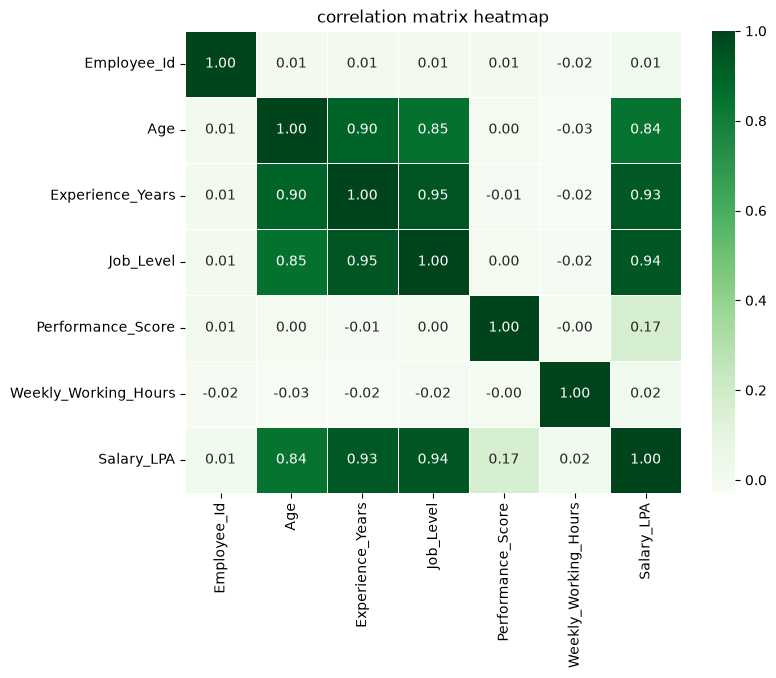

In [9]:
import  matplotlib.pyplot as plt
import seaborn as sns
corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Greens",
    fmt=".2f",
    linewidths=0.5
)
plt.title("correlation matrix heatmap")
plt.show()

Sorting

In [10]:
df.sort_values(by='Salary_LPA',ascending=False).head(10)

,Employee_Id,Age,Experience_Years,Education_Level,Job_Level,Department,Performance_Score,Weekly_Working_Hours,Salary_LPA
1158,1159,47,20,PhD,6,IT,7,40.7,55.18
917,918,45,20,Master,6,IT,9,34.1,54.79
743,744,42,18,PhD,6,IT,8,43.1,54.33
72,73,45,20,PhD,6,IT,6,39.7,54.00
675,676,41,16,PhD,6,Finance,10,42.1,53.81
1094,1095,37,18,PhD,6,IT,8,44.3,53.73
1126,1127,40,19,PhD,5,IT,9,45.0,53.71
639,640,43,16,PhD,6,IT,10,48.2,53.71
1358,1359,37,17,PhD,6,IT,8,41.6,53.48
405,406,44,19,PhD,5,IT,10,37.0,53.26


In [11]:
df.sort_values(by="Salary_LPA").head(10)

,Employee_Id,Age,Experience_Years,Education_Level,Job_Level,Department,Performance_Score,Weekly_Working_Hours,Salary_LPA
867,868,22,0,Bachelor,1,HR,1,43.2,5.29
1191,1192,24,1,Bachelor,1,HR,3,36.5,7.75
756,757,29,1,Bachelor,1,Marketing,2,44.2,8.57
841,842,23,1,Bachelor,1,Operations,2,39.9,9.19
294,295,23,2,Bachelor,1,HR,1,43.6,9.22
311,312,22,0,Bachelor,1,Operations,1,32.0,9.52
933,934,23,0,Bachelor,1,Finance,1,44.5,9.72
888,889,23,0,Bachelor,1,Operations,4,45.1,9.95
386,387,29,1,Bachelor,1,Operations,5,38.0,9.99
587,588,25,2,Bachelor,1,Marketing,3,39.1,10.08


Name changing

In [19]:
df.rename(columns={
    'Experience_Years':'Experience'
},inplace=True)

Outlier Treatment

In [12]:
q1 = df["Salary_LPA"].quantile(0.25)
q3 = df["Salary_LPA"].quantile(0.75)

IQR = q3 - q1

lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR

print("q1:", q1)
print("q3:", q3)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
outliers = df[
    (df["Salary_LPA"] < lower_limit) |
    (df["Salary_LPA"] > upper_limit)
]

print("\nSalary_LPA Outliers:",len(outliers))
print("\nSalary_LPA Outliers Data:\n")
print(outliers[[ "Employee_Id", "Salary_LPA"]].head(20))

q1: 21.055
q3: 39.105000000000004
Lower Limit: -6.020000000000007
Upper Limit: 66.18

Salary_LPA Outliers: 0

Salary_LPA Outliers Data:

Empty DataFrame
Columns: [Employee_Id, Salary_LPA]
Index: []


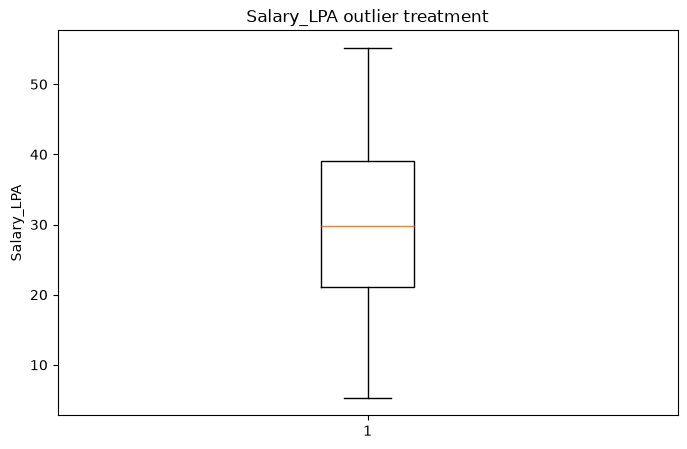

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.boxplot(df['Salary_LPA'])
plt.title("Salary_LPA outlier treatment")
plt.ylabel("Salary_LPA")
plt.show()

Bar Graph

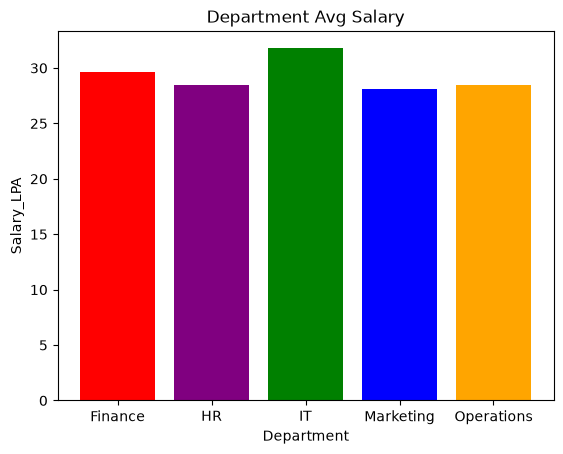

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
gender=df.groupby("Department")["Salary_LPA"].mean()
plt.bar(gender.index,
        gender.values,
        color=["red","purple","green","blue","orange"]
        )
plt.title("Department Avg Salary")
plt.xlabel("Department")
plt.ylabel("Salary_LPA")
plt.show()

PLOT

In [18]:
df.columns

Index(['Employee_Id', 'Age', 'Experience_Years', 'Education_Level',
       'Job_Level', 'Department', 'Performance_Score', 'Weekly_Working_Hours',
       'Salary_LPA'],
      dtype='str')


Average Salary by Experience:
Experience
0     15.483571
1     15.891053
2     17.042651
3     17.382836
4     21.584432
5     22.392813
6     23.108841
7     24.034321
8     28.510000
9     29.192222
10    29.211290
11    31.019143
12    34.667403
13    35.586333
14    36.744400
15    37.979661
16    41.950690
17    42.667333
18    42.394935
19    43.845968
20    47.300704
Name: Salary_LPA, dtype: float64


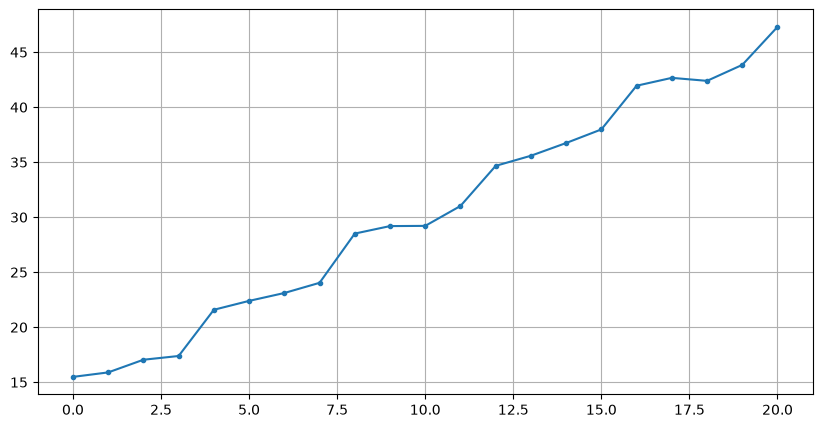

In [20]:
Experience_vs_Salary = df.groupby("Experience")["Salary_LPA"].mean()
print("\nAverage Salary by Experience:")
print(Experience_vs_Salary)
plt.figure(figsize=(10,5))
plt.plot(
    Experience_vs_Salary.index,
    Experience_vs_Salary.values,
    marker="."
)

plt.title = ("Average Salary by Experience ")
plt.xlabel = ("Experience")
plt.ylabel = ("Salary_LPA")
plt.grid(True)
plt.show()

Scatter

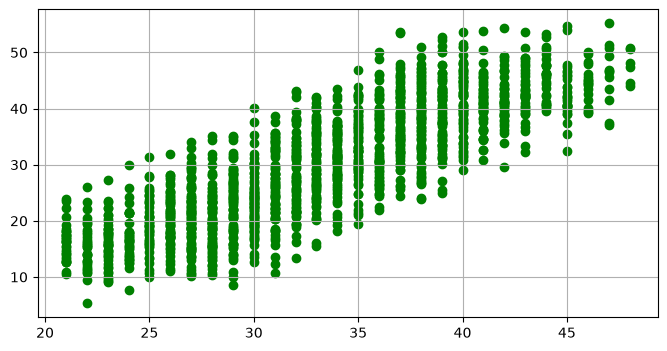

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.scatter(df["Age"], df["Salary_LPA"], color="green")

plt.title = ("Age vs Salary_LPA")
plt.xlabel = ("Age")
plt.ylabel = ("Salary_LPA")
plt.grid(True)

plt.show()

Pie chart

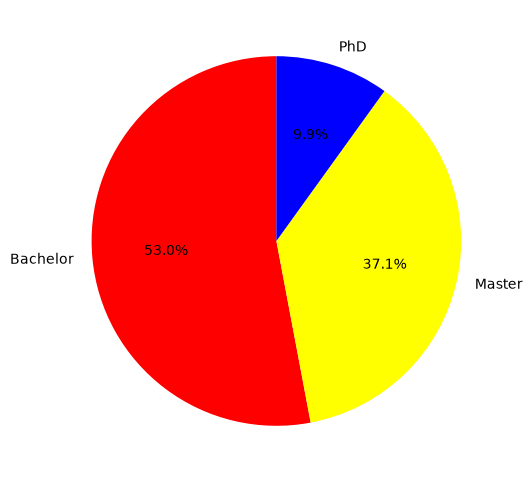

In [27]:

education= df["Education_Level"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(education,
        labels=education.index,
        autopct="%1.1f%%",
        colors=["red","yellow","blue"],
        startangle=90
        )

plt.title = ("Education Distribution")
plt.show()

All  info

First 5 Rows:
   Employee_Id  Age  Experience Education_Level  Job_Level Department  \
0            1   30           6        Bachelor          2         HR   
1            2   40          19        Bachelor          5  Marketing   
2            3   39          14             PhD          4    Finance   
3            4   38          10          Master          4         IT   
4            5   34           7        Bachelor          3         IT   

   Performance_Score  Weekly_Working_Hours  Salary_LPA  
0                  3                  43.1       18.71  
1                  8                  40.8       42.69  
2                  2                  44.8       39.37  
3                  4                  37.1       33.53  
4                  3                  48.5       25.56  

Last 5 Rows:
      Employee_Id  Age  Experience Education_Level  Job_Level  Department  \
1494         1495   36          16             PhD          5  Operations   
1495         1496   26           7   

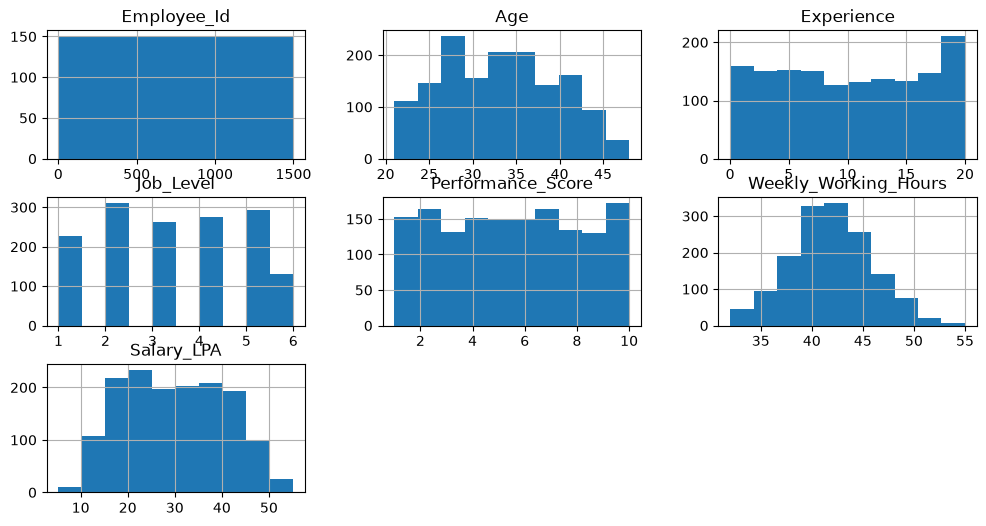

In [28]:
import seaborn as sns
print("First 5 Rows:")
print(df.head())
print("\nLast 5 Rows:")
print(df.tail())
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nShape of Dataset:")
print(df.shape)
df.hist(figsize=(12,6))
plt.title = ("Feature Distributions")
plt.show()